# AlphaLens Point-in-Time Feature Analysis

This notebook builds the model-input matrix from information available by each event's feature-as-of date. It examines feature coverage and univariate relationships without fitting a predictive model.

Feature families:

- trailing momentum, volatility, moving-average, volume, drawdown, beta, and SPY-relative signals;
- event type, fiscal quarter, calendar seasonality, and event spacing;
- token-weighted FinBERT sentiment, management-versus-analyst tone, and prior-event change;
- deterministic topic-level FinBERT aggregates for ten financial topics.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.features import (
    build_event_feature_dataset,
    model_feature_columns,
    summarize_feature_coverage,
    validate_feature_dataset,
)

pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid', context='notebook')

## Build the feature matrix

The model will receive only the explicit feature allowlist. Identifiers, future target dates, future prices, and the label itself are never selected as predictors.

In [2]:
dataset = build_event_feature_dataset(horizon=30, include_topics=True)
features = list(model_feature_columns(include_topics=True))
checks = validate_feature_dataset(dataset, include_topics=True)
print(f'{len(dataset):,} events | {int(dataset.target_available.sum()):,} labeled | {len(features)} features')
checks

758 events | 721 labeled | 58 features


{'rows': 758,
 'labeled_rows': 721,
 'duplicate_event_keys': 0,
 'feature_date_mismatch': 0,
 'feature_date_not_after_event': 0,
 'infinite_feature_values': 0}

In [3]:
identity = ['event_key', 'ticker', 'event_date', 'feature_as_of_date', 'event_source']
display(dataset[identity + features[:12] + ['excess_return_30d']].tail(8))

,event_key,ticker,event_date,feature_as_of_date,event_source,return_1d,momentum_5d,momentum_21d,momentum_63d,momentum_126d,volatility_21d,volatility_63d,sma_ratio_20d,sma_ratio_50d,sma_ratio_126d,volume_ratio_20d,volume_zscore_20d,excess_return_30d
750,earnings_call:234,CVX,2026-07-31,2026-08-03,earnings_call,-0.018544,0.016737,0.141726,0.022658,0.112812,0.250913,0.265096,0.035274,0.056862,0.037795,1.260644,1.531670,NaN
751,sec_filing:0000886982-26-000297,GS,2026-08-03,2026-08-04,sec_filing,0.025237,0.019006,-0.002189,0.170880,0.123484,0.499524,0.396550,-0.006613,0.001751,0.105472,1.280785,0.854290,NaN
752,earnings_call:326,CAT,2026-08-04,2026-08-05,earnings_call,-0.006229,0.112903,-0.071719,-0.035258,0.243946,0.437031,0.475327,-0.006793,-0.051084,0.047363,1.058364,0.157715,NaN
753,sec_filing:0000080424-26-000103,PG,2026-08-04,2026-08-05,sec_filing,-0.008175,0.004791,-0.031778,0.020675,-0.040629,0.214063,0.231039,-0.000804,0.001193,-0.003693,1.160794,0.546549,NaN
754,sec_filing:0000018230-26-000046,CAT,2026-08-05,2026-08-06,sec_filing,-0.016210,0.059100,-0.094433,-0.073771,0.243364,0.437109,0.473683,-0.018433,-0.065450,0.028739,0.920547,-0.212830,NaN
755,sec_filing:0000093410-26-000167,CVX,2026-08-06,2026-08-07,sec_filing,-0.014110,-0.052177,0.071876,0.031609,0.060707,0.255292,0.259458,-0.013987,0.020304,-0.000044,0.939218,-0.424911,NaN
756,sec_filing:0001628280-26-054343,JPM,2026-08-06,2026-08-07,sec_filing,0.003424,0.016288,0.065729,0.172595,0.163814,0.203436,0.223073,0.023228,0.075937,0.143652,0.564538,-1.426231,NaN
757,sec_filing:0000731766-26-000197,UNH,2026-08-10,2026-08-11,sec_filing,-0.016025,-0.013152,-0.062691,0.052146,0.478534,0.248333,0.261532,-0.038054,-0.026896,0.130353,0.630032,-0.790605,NaN


## Feature coverage

Some missingness is structural rather than erroneous. Filing rows have no management/analyst split, call rows have no 10-K/10-Q subtype, and a topic score is absent when that topic was not discussed. Later preprocessing must preserve these distinctions.

In [4]:
coverage = summarize_feature_coverage(dataset, include_topics=True)
display(coverage.style.format({'coverage': '{:.1%}'}))

,feature,non_null_rows,missing_rows,coverage
0,analyst_sentiment_score,331,390,45.9%
1,management_analyst_gap,331,390,45.9%
2,fiscal_quarter,339,382,47.0%
3,management_sentiment_score,339,382,47.0%
4,topic_technology_ai_sentiment,523,198,72.5%
5,topic_supply_chain_inventory_sentiment,585,136,81.1%
6,topic_pricing_inflation_sentiment,589,132,81.7%
7,topic_guidance_outlook_sentiment,633,88,87.8%
8,topic_costs_efficiency_sentiment,640,81,88.8%
9,topic_capital_allocation_sentiment,641,80,88.9%


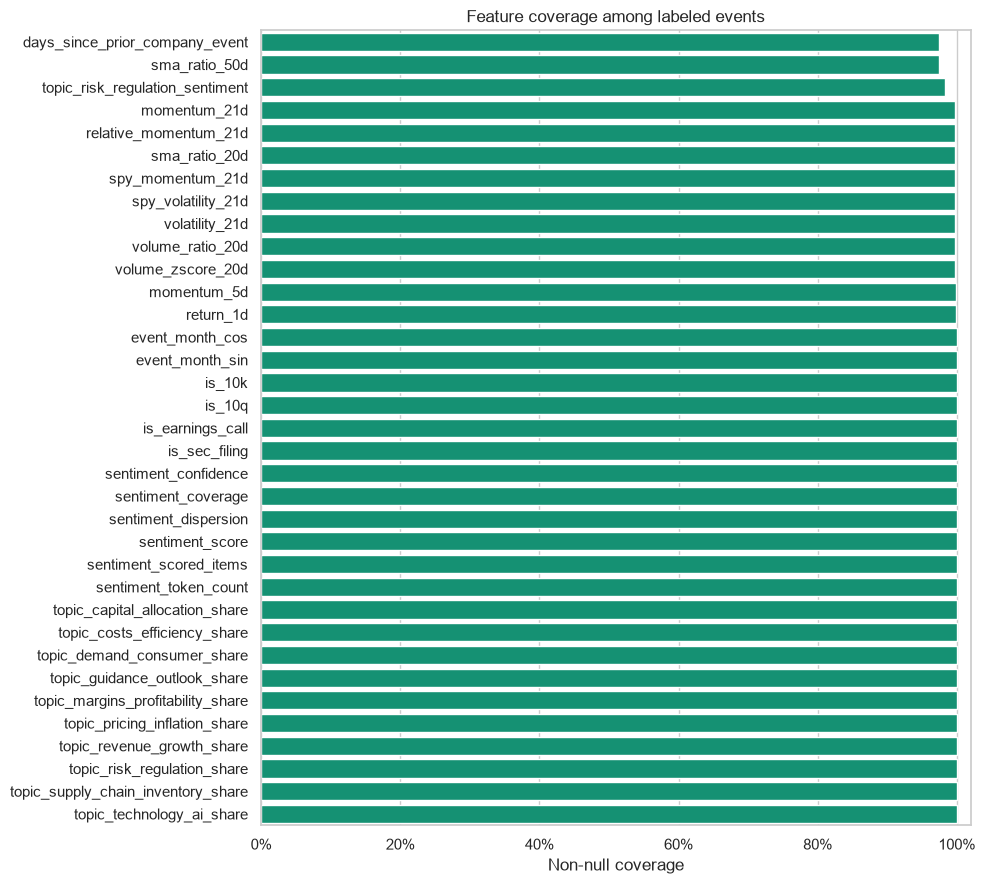

In [5]:
plot_coverage = coverage.sort_values('coverage').tail(35)
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=plot_coverage, x='coverage', y='feature', color='#00a67e', ax=ax)
ax.set(title='Feature coverage among labeled events', xlabel='Non-null coverage', ylabel='')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.set_xlim(0, 1.02)
plt.tight_layout()
plt.show()

## Market features at the event anchor

Every market indicator is trailing and evaluated at `feature_as_of_date`, which must equal the post-event anchor session. Future-price mutation tests verify that later prices cannot alter these values.

In [6]:
market_columns = [
    'momentum_21d', 'momentum_63d', 'volatility_21d',
    'sma_ratio_50d', 'volume_zscore_20d', 'drawdown_126d',
    'beta_63d', 'relative_momentum_63d',
]
display(dataset.loc[dataset.target_available, market_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
momentum_21d,719.0,0.025459,0.111415,-0.424497,-0.031151,0.016625,0.080865,0.513307
momentum_63d,697.0,0.049966,0.178312,-0.561528,-0.051750,0.032939,0.142730,1.060194
volatility_21d,719.0,0.333038,0.182405,0.060054,0.206127,0.280379,0.413216,1.259659
sma_ratio_50d,703.0,0.019904,0.095104,-0.404496,-0.031492,0.016659,0.070484,0.487448
volume_zscore_20d,719.0,1.020063,1.413490,-1.670326,-0.105353,0.757789,1.916234,4.211945
drawdown_126d,676.0,-0.103615,0.110668,-0.688415,-0.146401,-0.073389,-0.021693,0.000000
beta_63d,697.0,0.988073,0.687617,-0.792763,0.461535,0.981150,1.382537,3.233509
relative_momentum_63d,697.0,0.020149,0.157346,-0.549003,-0.071798,0.006247,0.097114,0.955161


## Univariate relationship with the label

These correlations are exploratory, not evidence of out-of-sample predictiveness. Model selection will use chronological validation with purged boundaries.

In [7]:
labeled = dataset.loc[dataset.target_available].copy()
correlations = (
    labeled[features + ['excess_return_30d']]
    .corr(numeric_only=True)['excess_return_30d']
    .drop('excess_return_30d')
    .dropna()
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
display(correlations.head(20).rename('pearson_correlation').to_frame())

,pearson_correlation
momentum_5d,0.149651
sma_ratio_20d,0.129158
return_1d,0.109687
volatility_63d,0.084762
relative_momentum_21d,0.078997
days_since_prior_source_event,0.077395
event_month_sin,-0.074039
sentiment_change_from_prior,0.069832
topic_guidance_outlook_share,-0.067501
sma_ratio_50d,0.066731


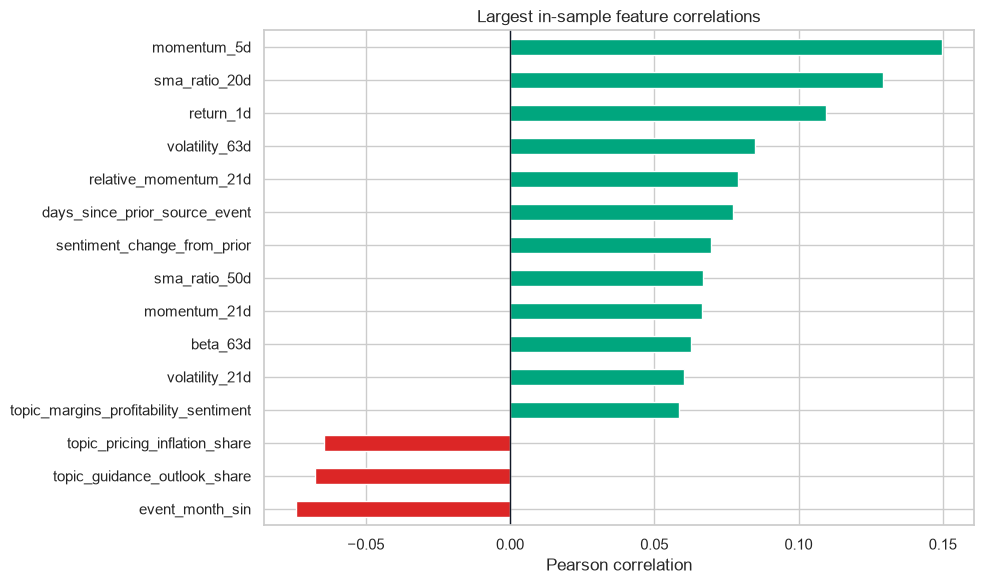

In [8]:
top_correlations = correlations.head(15).sort_values()
colors = ['#dc2626' if value < 0 else '#00a67e' for value in top_correlations]
ax = top_correlations.plot(kind='barh', figsize=(10, 6), color=colors)
ax.axvline(0, color='#111827', linewidth=1)
ax.set(title='Largest in-sample feature correlations', xlabel='Pearson correlation', ylabel='')
plt.tight_layout()
plt.show()

## FinBERT features

Event sentiment is token weighted. Earnings calls additionally expose management tone, analyst tone, and their gap. Topic sentiment uses the existing explainable keyword taxonomy to group FinBERT-scored text; the topic classifier itself is not FinBERT.

In [9]:
sentiment_rows = labeled.dropna(subset=['sentiment_score']).copy()
sentiment_rows['sentiment_quintile'] = pd.qcut(
    sentiment_rows['sentiment_score'], 5, labels=False, duplicates='drop'
) + 1
sentiment_quintiles = (
    sentiment_rows.groupby(['event_source', 'sentiment_quintile'], as_index=False)
    .agg(
        events=('event_key', 'size'),
        mean_sentiment=('sentiment_score', 'mean'),
        mean_excess_return=('excess_return_30d', 'mean'),
    )
)
display(sentiment_quintiles.style.format({
    'mean_sentiment': '{:.3f}',
    'mean_excess_return': '{:.2%}',
}))

,event_source,sentiment_quintile,events,mean_sentiment,mean_excess_return
0,earnings_call,2,7,-0.115,0.06%
1,earnings_call,3,55,0.080,-0.38%
2,earnings_call,4,133,0.246,0.93%
3,earnings_call,5,144,0.426,0.38%
4,sec_filing,1,145,-0.381,-0.28%
5,sec_filing,2,137,-0.124,0.41%
6,sec_filing,3,89,0.026,0.44%
7,sec_filing,4,11,0.190,1.17%


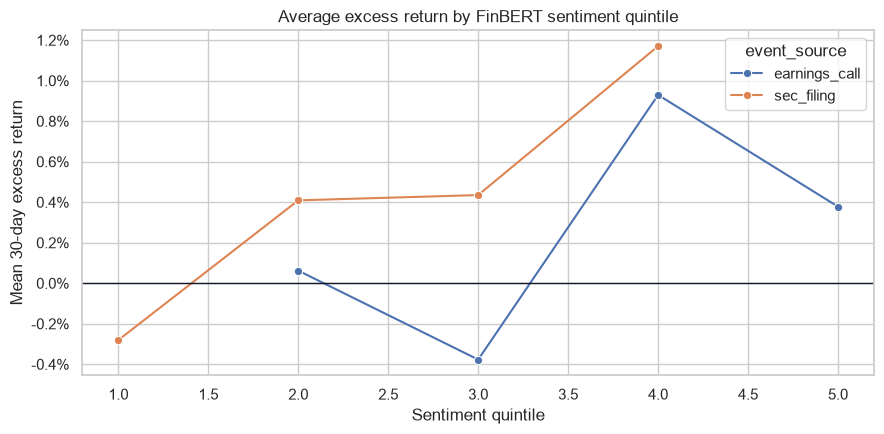

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(
    data=sentiment_quintiles, x='sentiment_quintile',
    y='mean_excess_return', hue='event_source', marker='o', ax=ax
)
ax.axhline(0, color='#111827', linewidth=1)
ax.set(title='Average excess return by FinBERT sentiment quintile', xlabel='Sentiment quintile', ylabel='Mean 30-day excess return')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
plt.tight_layout()
plt.show()

## Decision for the next stage

The feature matrix is ready for baseline modeling. The next step is to define chronological train, validation, and test periods with a 30-session purge; fit naive and linear baselines; and record MAE, RMSE, directional accuracy, and rank correlation before introducing XGBoost.